In [1]:
!source CalceVENV/bin/activate

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#                              Import libraries
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from stable_baselines3 import SAC
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import warnings
warnings.filterwarnings('ignore')
 
from BatteryEnvironment import BatteryEnv

from llm_coordinator import HierarchicalLLMSACController

In [3]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self, eval_env, eval_freq=500, verbose=0):
        super().__init__(verbose)
        self.eval_env     = eval_env
        self.eval_freq    = eval_freq
        self.reward_log   = []   # средняя награда на eval
        self.steps_log    = []   # номер шага

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            rewards = []
            for _ in range(5):  # 5 эпизодов для оценки
                obs, _ = self.eval_env.reset()
                done, total = False, 0.0
                while not done:
                    action, _ = self.model.predict(obs, deterministic=True)
                    obs, r, terminated, truncated, _ = self.eval_env.step(action)
                    total += r
                    done = terminated or truncated
                rewards.append(total)
            mean_r = np.mean(rewards)
            self.reward_log.append(mean_r)
            self.steps_log.append(self.n_calls)
            if self.verbose:
                print(f"  Шаг {self.n_calls:6d} | Средняя награда: {mean_r:.2f}")
        return True

In [4]:
def train_sac(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение SAC-агента (Multi-Battery)")
    print("=" * 60)

    # 1. Передаем список ID батарей (например, две разные или одинаковые)
    battery_ids = ["CS2_35", "CS2_36"]
    
    # 2. Создаем среду
    train_env = Monitor(BatteryEnv(cell_ids=battery_ids))
    eval_env  = BatteryEnv(cell_ids=battery_ids)

    # 3. SAC подхватит новую размерность автоматически из env.action_space
    # Тебе НЕ НУЖНО менять код SAC, он сам увидит, что action_space теперь shape=(2,)
    model = SAC(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        buffer_size=50_000,
        learning_starts=500,
        batch_size=256,
        tau=0.005,
        gamma=0.999,
        ent_coef="auto",
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=0,
    )

    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("sac_multi_battery_model") # Лучше переименовать файл
    print("\nМодель сохранена: sac_multi_battery_model.zip")

    return model, callback

In [5]:
def train_ppo(total_timesteps=30_000):
    print("=" * 60)
    print("  Этап 3: Обучение PPO-агента (Multi-Battery)")
    print("=" * 60)

    # Передаем список ID батарей (гетерогенная система)
    battery_ids = ["CS2_35", "CS2_36"]
    
    # Инициализируем среду с двумя каналами
    train_env = Monitor(BatteryEnv(cell_ids=battery_ids))
    eval_env  = BatteryEnv(cell_ids=battery_ids)

    # PPO автоматически адаптируется к новой размерности action_space (2)
    # и observation_space (8)
    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=2048, 
        batch_size=64,
        n_epochs=10,
        gamma=0.999,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        policy_kwargs=dict(net_arch=[256, 256]),
        verbose=0,
    )

    callback = RewardLoggerCallback(eval_env, eval_freq=500, verbose=1)

    print(f"\nОбучение {total_timesteps:,} шагов...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    model.save("ppo_multi_battery_model") # Переименовали файл, чтобы не перезаписать старый
    print("\nМодель сохранена: ppo_multi_battery_model.zip")

    return model, callback

In [6]:
def run_random(env, n_episodes=10):
    """Случайный агент."""
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = env.action_space.sample()
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)


def rule_based_policy(obs):
    hour = round(float(obs[5]))
    if hour <= 6:
        return np.array([1.0, 1.0], dtype=np.float32)   # заряд ночью
    if 18 <= hour <= 22:
        return np.array([-1.0, -1.0], dtype=np.float32)  # разряд в пик
    return np.array([0.0, 0.0], dtype=np.float32)        # пауза


def run_rule_based(env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = rule_based_policy(obs)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

def run_sac(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

def run_ppo(model, env, n_episodes=10):
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, _ = env.step(action)
            total += r
            done = terminated or truncated
        rewards.append(total)
    return np.mean(rewards)

In [7]:
def run_episode_detailed(env, policy_func):
    obs, _ = env.reset()
    done = False
    
    history = {
        'hour': [],
        'soc': [],
        'action': [],
        'total_reward': 0.0,
        'total_cost_rub': 0.0,
        'total_wear_rub': 0.0
    }
    
    while not done:
        action = policy_func(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        history['hour'].append(obs[7]) # час системы
        history['action'].append(action)
        history['soc'].append([bat['soc'] for bat in env.batteries])
        
        # Аккумулируем данные за сутки из info
        history['total_reward'] += reward
        history['total_cost_rub'] += info.get('cost_rub', 0.0)
        history['total_wear_rub'] += info.get('wear_rub', 0.0)
        
        obs = next_obs
        
    return history

In [8]:
def compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo):
    # Инициализируем среду
    cell_ids = ["CS2_35", "CS2_36"]
    env = BatteryEnv(cell_ids=cell_ids)

    print("\nОценка стратегий (10 эпизодов каждая)...")
    r_random = run_random(env)
    r_rule   = run_rule_based(env)
    r_sac    = run_sac(model_sac, env)
    r_ppo    = run_ppo(model_ppo, env)

    print(f"  Random:     {r_random:.2f}")
    print(f"  Rule-Based: {r_rule:.2f}")
    print(f"  PPO:        {r_ppo:.2f}")
    print(f"  SAC:        {r_sac:.2f}")

    # Детальные прогоны для графиков
    h_random = run_episode_detailed(env, lambda obs: env.action_space.sample())
    h_rule   = run_episode_detailed(env, rule_based_policy)
    h_ppo    = run_episode_detailed(env, lambda obs: model_ppo.predict(obs, deterministic=True)[0])
    h_sac    = run_episode_detailed(env, lambda obs: model_sac.predict(obs, deterministic=True)[0])

    # Таблица декомпозиции
    print("\nДЕКОМПОЗИЦИЯ REWARD (в рублях)")
    print("=" * 65)
    print(f"{'Стратегия':<14} {'Reward':>10} {'Затраты₽':>10} {'Износ₽':>10} {'Бонус₽':>10}")
    print("-" * 65)
    for name, h in [('Random', h_random), ('Rule-Based', h_rule), ('PPO', h_ppo), ('SAC', h_sac)]:
        # Защита на случай, если ключей нет в словаре h
        total_rew = h.get('total_reward', 0.0)
        cost_rub  = h.get('total_cost_rub', 0.0)
        wear_rub  = h.get('total_wear_rub', 0.0)
        bonus_rub = h.get('total_bonus_rub', 0.0)
        print(f"{name:<14} {total_rew:>10.2f} {cost_rub:>10.2f} {wear_rub:>10.4f} {bonus_rub:>10.2f}")
    print("=" * 65)

    colors = {'random': '#AAAAAA', 'rule': '#E24B4A', 'ppo': '#EF9F27', 'sac': '#1D9E75'}
    fig = plt.figure(figsize=(18, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Кривые обучения
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(cb_sac.steps_log, cb_sac.reward_log, color=colors['sac'], lw=2.5, label='SAC')
    ax1.plot(cb_ppo.steps_log, cb_ppo.reward_log, color=colors['ppo'], lw=2.5, label='PPO')
    ax1.set_title('Кривые обучения SAC vs PPO', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # 2. Итоговая награда
    ax2 = fig.add_subplot(gs[1, 0])
    values = [r_random, r_rule, r_ppo, r_sac]
    ax2.bar(['Random', 'Rule-Based', 'PPO', 'SAC'], values, color=[colors['random'], colors['rule'], colors['ppo'], colors['sac']])
    ax2.set_title('Итоговая награда за сутки (₽)', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.2, axis='y')

    # 3. Средний SOC по двум батареям
    ax3 = fig.add_subplot(gs[1, 1])
    for name, h, ls in [('Rule', h_rule, '--'), ('PPO', h_ppo, '-.'), ('SAC', h_sac, '-')]:
        hours = np.array(h['hour'])
        soc_arr = np.array(h['soc'])
        
        if soc_arr.ndim > 1 and soc_arr.shape[1] > 1:
            avg_soc = np.mean(soc_arr, axis=1)
        else:
            avg_soc = soc_arr.flatten()
            
        ax3.plot(hours, avg_soc, lw=2, ls=ls, label=f'{name} (avg)')
    ax3.set_title('Средний SOC системы', fontsize=12, fontweight='bold')
    ax3.set_ylim(-0.05, 1.1)
    ax3.legend()
    ax3.grid(alpha=0.3)

    # 4. Действия SAC по батареям (Исправленный блок)
    ax4 = fig.add_subplot(gs[2, 0])
    hours_sac = np.array(h_sac['hour'])
    actions_sac = np.array(h_sac['action'])
    
    # Проверяем размерность массива действий
    if actions_sac.ndim > 1 and actions_sac.shape[1] >= 2:
        ax4.bar(hours_sac - 0.2, actions_sac[:, 0], width=0.4, color='#1D9E75', alpha=0.7, label='Батарея 1')
        ax4.bar(hours_sac + 0.2, actions_sac[:, 1], width=0.4, color='#88C999', alpha=0.7, label='Батарея 2')
    else:
        # Фолбэк, если пришло одномерное действие
        ax4.bar(hours_sac, actions_sac.flatten(), width=0.6, color='#1D9E75', alpha=0.7, label='Все батареи')
        
    ax4.set_title('Действия SAC по батареям', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Час')
    ax4.set_ylabel('Действие (Power)')
    ax4.legend()
    ax4.grid(alpha=0.3)

    # 5. Декомпозиция затрат
    ax5 = fig.add_subplot(gs[2, 1])
    x = np.arange(4)
    width = 0.35
    
    costs = [h.get('total_cost_rub', 0.0) for h in [h_random, h_rule, h_ppo, h_sac]]
    wears = [h.get('total_wear_rub', 0.0) for h in [h_random, h_rule, h_ppo, h_sac]]
    
    ax5.bar(x - width/2, costs, width, label='Затраты на сеть', color='#E24B4A')
    ax5.bar(x + width/2, wears, width, label='Износ батарей', color='#EF9F27')
    ax5.set_xticks(x)
    ax5.set_xticklabels(['Random', 'Rule', 'PPO', 'SAC'])
    ax5.set_title('Декомпозиция расходов (₽)', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(alpha=0.3)

    plt.suptitle('Сравнение стратегий управления системой из 2-х батарей', fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('sac_ppo_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'random': r_random, 'rule_based': r_rule, 'ppo': r_ppo, 'sac': r_sac}

  Этап 3: Обучение SAC-агента (Multi-Battery)

Обучение 30,000 шагов...
  Шаг    500 | Средняя награда: -3.20
  Шаг   1000 | Средняя награда: 2.44
  Шаг   1500 | Средняя награда: 19.58
  Шаг   2000 | Средняя награда: 34.41
  Шаг   2500 | Средняя награда: 36.54
  Шаг   3000 | Средняя награда: 36.97
  Шаг   3500 | Средняя награда: 38.33
  Шаг   4000 | Средняя награда: 38.98
  Шаг   4500 | Средняя награда: 39.18
  Шаг   5000 | Средняя награда: 39.53
  Шаг   5500 | Средняя награда: 37.04
  Шаг   6000 | Средняя награда: 37.81
  Шаг   6500 | Средняя награда: 38.64
  Шаг   7000 | Средняя награда: 39.38
  Шаг   7500 | Средняя награда: 42.07
  Шаг   8000 | Средняя награда: 41.87
  Шаг   8500 | Средняя награда: 40.25
  Шаг   9000 | Средняя награда: 41.98
  Шаг   9500 | Средняя награда: 40.98
  Шаг  10000 | Средняя награда: 42.11
  Шаг  10500 | Средняя награда: 42.34
  Шаг  11000 | Средняя награда: 42.36
  Шаг  11500 | Средняя награда: 41.92
  Шаг  12000 | Средняя награда: 42.00
  Шаг  12500 | Ср

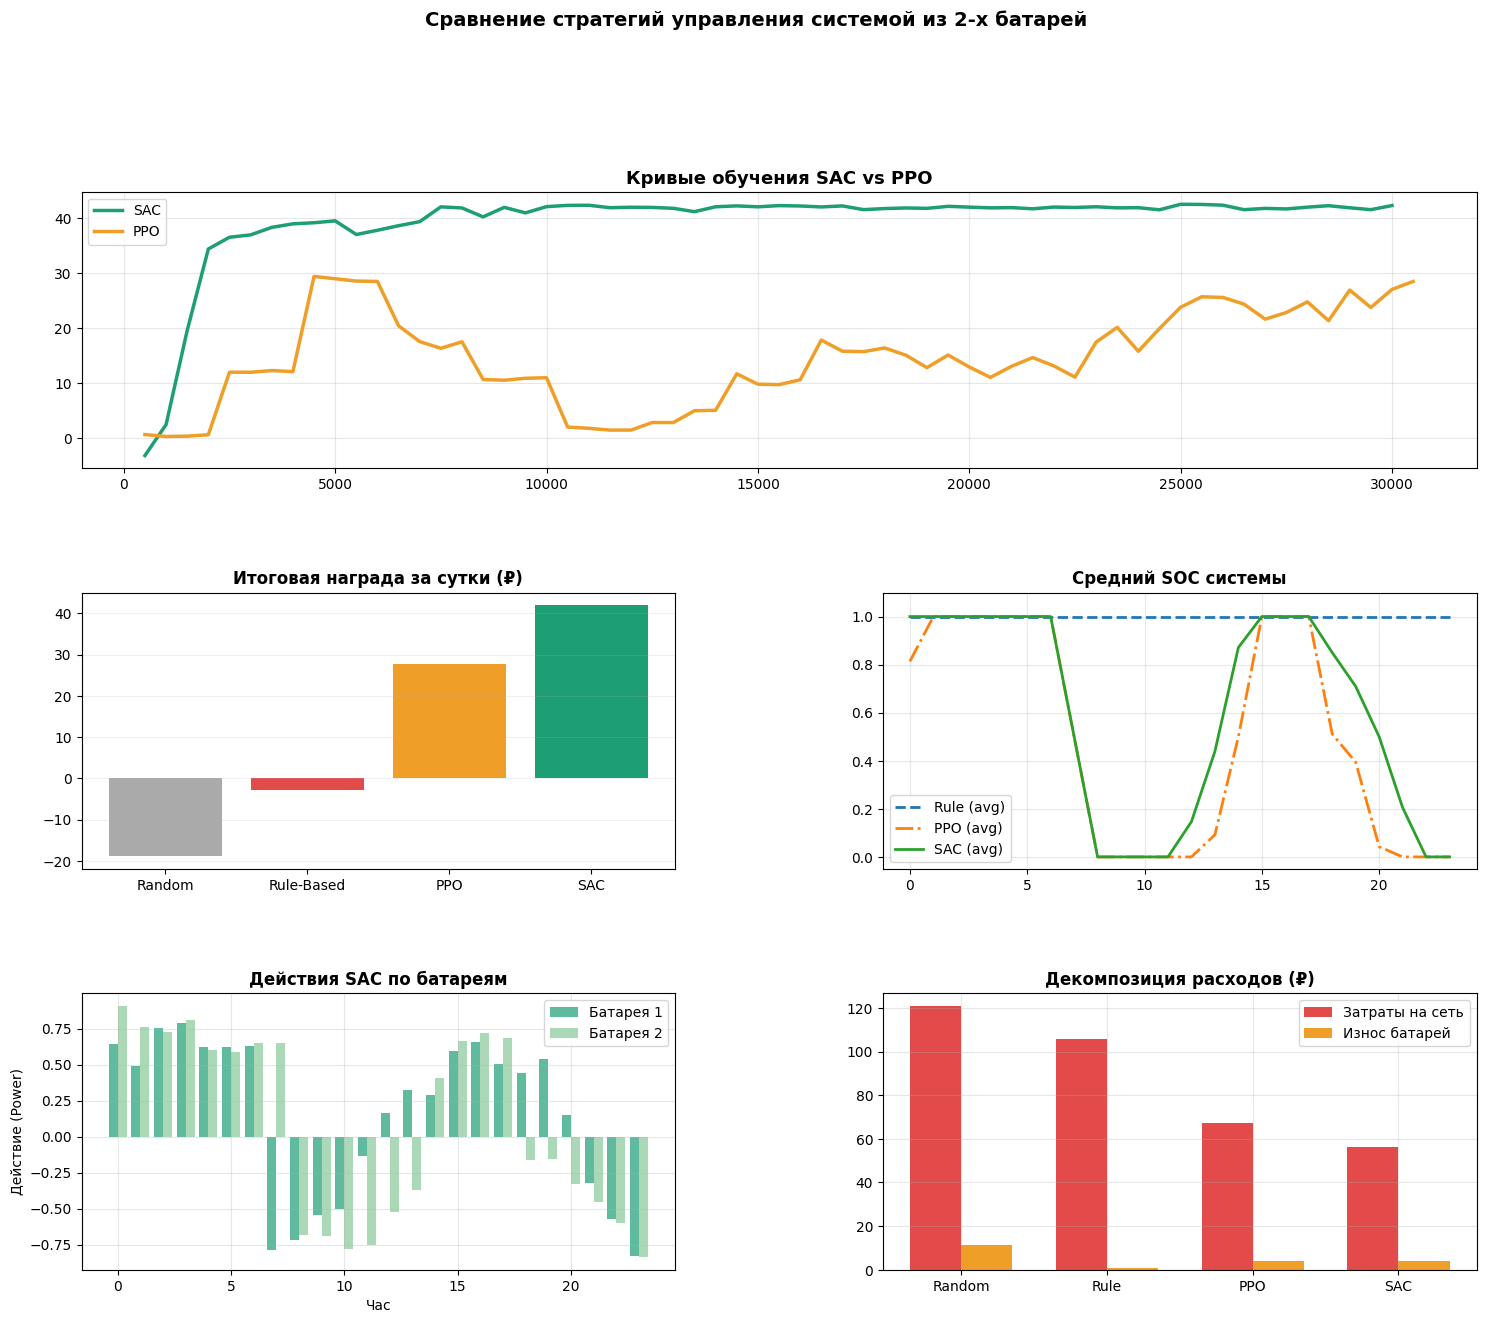

In [9]:
model_sac, cb_sac = train_sac(total_timesteps=30_000)
model_ppo, cb_ppo = train_ppo(total_timesteps=30_000)
results = compare_and_plot(model_sac, cb_sac, model_ppo, cb_ppo)

Агенты

In [10]:
from openai import OpenAI
import re

# Подключаемся к твоему llama-server
client = OpenAI(base_url="http://127.0.0.1:8000/v1", api_key="not-needed")

def ask_qwen(prompt, system_role="Ты эксперт по системам накопления энергии и RL-алгоритмам."):
    """
    Универсальная функция для общения с моделью.
    """
    try:
        response = client.chat.completions.create(
            model="qwen", # название может быть любым для локального сервера
            messages=[
                {"role": "system", "content": system_role},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3, # низкая температура для точности
            max_tokens=500
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Ошибка при запросе: {e}"

In [11]:
import matplotlib.pyplot as plt

def plot_load_shaving(env, history, title="Срез пиков (Load Shaving)"):
    hours = np.arange(24)
    load = 1.0 + np.sin(hours * np.pi / 12) * 0.5
    
    # Действия (сумма действий двух батарей)
    actions = np.sum(history['action'], axis=1) * 2.0 
    
    plt.figure(figsize=(10, 5))
    plt.plot(hours, load, label='Исходная нагрузка', color='black', linestyle='--')
    plt.plot(hours, load + actions, label='Нагрузка после работы АКБ', color='green', linewidth=2)
    
    # Заливка действий
    plt.fill_between(hours, load, load + actions, 
                     where=(actions >= 0), color='orange', alpha=0.3, label='Разряд (пик)')
    plt.fill_between(hours, load, load + actions, 
                     where=(actions < 0), color='blue', alpha=0.3, label='Заряд (ночь)')
    
    plt.title(title)
    plt.xlabel("Час суток")
    plt.ylabel("Мощность (кВт)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
from llm_analyst import StrategicAnalyst
from IPython.display import Markdown, display

# ── Шаг 1: сборка лога в формате для аналитика ─────────────────────────────
def run_episode_for_analyst(env, policy_func):
    """
    Прогоняет один суточный эпизод и собирает лог в формате,
    который ожидает llm_analyst.py (REQUIRED_FIELDS).
    """
    obs, _ = env.reset()
    done = False
    logs = []

    while not done:
        load, pv, price, hour = obs[4], obs[5], obs[6], obs[7]
        action = policy_func(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        cost_without = max(0.0, load - pv) * price  # без АКБ — независимо от действия

        logs.append({
            "hour":         int(hour),
            "soc_35":       info["soc_35"],
            "soh_35":       info["soh_35"],
            "soc_36":       info["soc_36"],
            "soh_36":       info["soh_36"],
            "load":         float(load),
            "pv":           float(pv),
            "price":        float(price),
            "action_35":    float(action[0]),
            "action_36":    float(action[1]),
            "cost_with":    info["cost_rub"],
            "cost_without": cost_without,
            "wear_cost":    info["wear_rub"],
            "reward":       info["reward"],
        })
        obs = next_obs

    return logs

Час 0 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 1 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 2 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 3 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 4 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 5 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 6 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 7 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 8 | Сырой ответ LLM: {"mask_b1": 0, "mask_b2": 1}
   -> Маска применена: [0.0, 1.0]
Час 9 | Сырой ответ LLM: {"mask_b1": 0, "mask_b2": 1}
   -> Маска применена: [0.0, 1.0]
Час 10 | Сырой ответ LLM: {"mask_b1": 0, "mask_b2": 1}
   -> Маска применена: [0.0, 1.0]
Час 11 | Сырой ответ LLM: {"mas

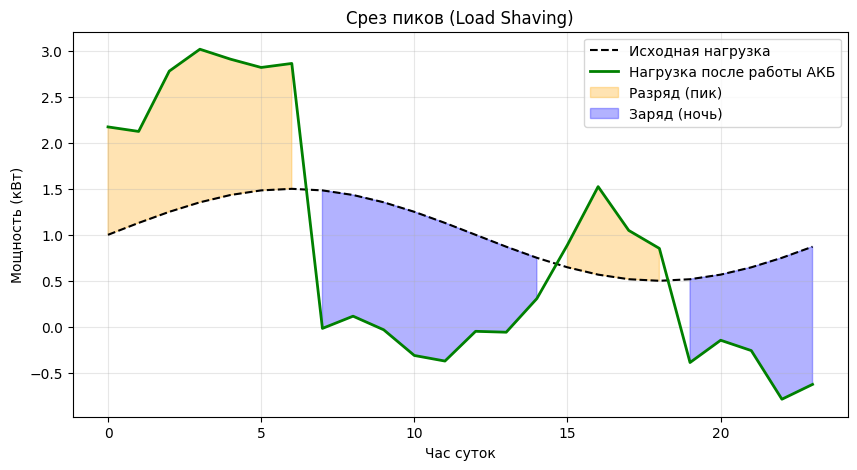

In [13]:
def ask_qwen_wrapped(prompt, system_role):
    return ask_qwen(prompt, system_role=system_role)

hybrid_agent = HierarchicalLLMSACController(
    sac_model=model_sac,
    ask_fn=ask_qwen_wrapped,
)

battery_ids = ["CS2_35", "CS2_36"]
env = BatteryEnv(cell_ids=battery_ids)
history_hybrid = run_episode_detailed(env, hybrid_agent.select_action)
plot_load_shaving(env, history_hybrid)

In [14]:
for i in range(0, 24):
    print(f"Час {i}: action_raw={history_hybrid['action'][i]}, "
          f"soc={history_hybrid['soc'][i]}")

Час 0: action_raw=[0.5866046 0.       ], soc=[1.0, 0.6114925221630232]
Час 1: action_raw=[0.49729919 0.        ], soc=[1.0, 0.6114925221630232]
Час 2: action_raw=[0.76491427 0.        ], soc=[1.0, 0.6114925221630232]
Час 3: action_raw=[0.83218098 0.        ], soc=[1.0, 0.6114925221630232]
Час 4: action_raw=[0.73830462 0.        ], soc=[1.0, 0.6114925221630232]
Час 5: action_raw=[0.66831362 0.        ], soc=[1.0, 0.6114925221630232]
Час 6: action_raw=[0.68163061 0.        ], soc=[1.0, 0.6114925221630232]
Час 7: action_raw=[-0.7503103  0.       ], soc=[0.0, 0.6114925221630232]
Час 8: action_raw=[-0.         -0.65884614], soc=[0.0, 0.0]
Час 9: action_raw=[-0.         -0.69311178], soc=[0.0, 0.0]
Час 10: action_raw=[-0.         -0.78100717], soc=[0.0, 0.0]
Час 11: action_raw=[-0.         -0.75099301], soc=[0.0, 0.0]
Час 12: action_raw=[ 0.         -0.52462763], soc=[0.0, 0.0]
Час 13: action_raw=[ 0.        -0.4648214], soc=[0.0, 0.0]
Час 14: action_raw=[ 0.         -0.22165233], soc=[0.0, 

In [15]:
from llm_analyst import StrategicAnalyst
from IPython.display import Markdown, display

daily_logs = run_episode_for_analyst(env, hybrid_agent.select_action)
print(f"Готово: {len(daily_logs)} записей (гибридный агент, с маскированием).")

analyst = StrategicAnalyst(base_url="http://127.0.0.1:8001/v1", model="Qwen2.5-3B-Instruct-Q5_K_M.gguf")
report_md = analyst.generate_report(daily_logs)
display(Markdown(report_md))

Час 0 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 1 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 2 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 3 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 4 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 5 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 6 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 7 | Сырой ответ LLM: {"mask_b1": 1, "mask_b2": 0}
   -> Маска применена: [1.0, 0.0]
Час 8 | Сырой ответ LLM: {"mask_b1": 0, "mask_b2": 1}
   -> Маска применена: [0.0, 1.0]
Час 9 | Сырой ответ LLM: {"mask_b1": 0, "mask_b2": 1}
   -> Маска применена: [0.0, 1.0]
Час 10 | Сырой ответ LLM: {"mask_b1": 0, "mask_b2": 1}
   -> Маска применена: [0.0, 1.0]
Час 11 | Сырой ответ LLM: {"mas

## Раздел 1. Технико-экономический баланс суток
Система экономически эффективна, срезы пиковых затрат значительны и способствуют значительному увеличению выгода. Однако износ батарей также заметен, что требует внимания к долгосрочным вопросам надежности энергоустановок.

## Раздел 2. Анализ динамики распределения ресурсов (SOC & SOH)
Асимметрия износа между батареями не выявленна, но есть проблемы с критическим разрядом и пустотой батарей в пиковые часы.

## Раздел 3. Аудит тактического LLM-диспетчера
На основании данных, тактический слой действительно парализовал батарею CS2_36 слишком надолго, что может быть небезопасно для её долгосрочной эффективности и экономичности.

## Раздел 4. Предписания по оптимизации
Предлагаю увеличить порог SOH для батарей CS2_35 и CS2_36 на 10% для снижения износа и уменьшения награды за критический разряд.